# Climate Signal — THI → Production & Welfare

Consolidated climate notebook. Merges the useful, de-duplicated code from
`Climate_Signal_Validation.ipynb`, `Correlation_analysis.ipynb`, `NonLinear_Correlation.ipynb`,
`Lagged_Heat_Effects.ipynb`, and `THI_AnimalVar_Averages.ipynb` into one ordered analysis.
Originals are kept in `raw/`.

The parts follow the real methodological arc — **why raw correlations mislead, and how to fix it:**

1. **Data confidence & weather-merge audit** — is the data trustworthy?
2. **Linear correlations & non-linearity** — the raw picture (Pearson/Spearman, mutual information).
3. **The season confound** — annual `r ≈ 0` because summer (−) cancels winter (+).
4. **The fix: THI anomaly + Matera positive control** — heat above the farm-month normal flips the
   sign back to the correct biology (milk ↓, SCS ↑), reproducing Matera 2022.
5. **Clean within-animal effects & variance structure** — animal fixed effects, LMM, ICC.
6. **Cumulative & lagged heat exposure** — heat is cumulative; find the best window per trait.
7. **Non-linear dose-response & thresholds** — is the *causal* curve curved, or linear? (aim 5)
8. **Extreme events** — heat waves & cold snaps (intensity vs exposure).
9. **Regional heat sensitivity** — cluster-curve-controlled, per region + Campania/Lazio split.
10. **Farm heterogeneity** — per-farm weather-response slopes.

> **Correctness rules used throughout:** causal heat effects use the **THI anomaly** (not raw same-day
> THI); analyses are **summer-stratified** or season-controlled; heat exposure is **cumulative**;
> lactation stage (DIM) and parity are controlled; **within-animal** demeaning with **farm-clustered** SE.

## Setup — imports, config, shared load & helpers

In [1]:
import os, glob, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns; HAVE_SNS = True
except Exception:
    HAVE_SNS = False
try:
    import statsmodels.formula.api as smf; HAVE_SM = True
except Exception:
    HAVE_SM = False

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
RANDOM_STATE = 42

MERGED   = '../../Thesis_Data/Final_Data/Final_Merged_Data.csv'   # test-day records + merged weather + Region
PROC     = '../../Thesis_Data/Final_Data/After_Processing.csv'    # production only
WDIR     = '../../Thesis_Data/farm_weather_indices'               # per-farm DAILY weather series
THI_COL  = 'THI_1_avg'      # test-day THI (NRC 1971 = Matera 2022 formula)
THI_DAILY = 'THI_1_max'     # daily-max heat load for trailing windows / events
SUMMER   = [6, 7, 8, 9]
print(f'statsmodels: {HAVE_SM} | seaborn: {HAVE_SNS}')

statsmodels: True | seaborn: True


In [2]:
# ---- Primary load: test-day records with merged weather (+ Region) ----
df = pd.read_csv(MERGED)
if df['AFC'].dtype == object:
    df['AFC'] = pd.to_timedelta(df['AFC'], errors='coerce').dt.days
df['dtt']   = pd.to_datetime(df['dtt'], errors='coerce')
df['month'] = df['dtt'].dt.month
df['farm']  = df['Farm_Code'].astype(str).str.replace(r'\.0$', '', regex=True)
df['date']  = df['dtt'].dt.normalize()

def assign_season(m):
    return 'Winter' if m in [12, 1, 2] else 'Spring' if m in [3, 4, 5] else 'Summer' if m in [6, 7, 8] else 'Autumn'
df['season'] = pd.Categorical(df['month'].map(assign_season),
                              categories=['Winter', 'Spring', 'Summer', 'Autumn'], ordered=True)

# The stored lag columns are LEAKY (self-filled at each lactation start -> r inflated 0.69 -> 0.75).
# Recompute them WITHIN lactation (Animal x parity), same as COEF.ipynb. NaN at a lactation's first
# test-days is correct and is left as-is (never back-filled -> no leakage).
df = df.sort_values(['Farm_Code', 'Animal_ID', 'parity', 'dtt']).reset_index(drop=True)
_lac = df.groupby(['Farm_Code', 'Animal_ID', 'parity'])
for _c in ['milk_kg', 'protein_p']:
    df[f'{_c}_lag1'] = _lac[_c].shift(1)
    df[f'{_c}_lag2'] = _lac[_c].shift(2)

print(f'{len(df):,} records | {df.Animal_ID.nunique():,} animals | {df.Farm_Code.nunique()} farms')
print(f"lag1 vs milk (within-lactation, de-leaked): {df[['milk_kg','milk_kg_lag1']].dropna().corr().iloc[0,1]:.4f}")

1,631,410 records | 90,532 animals | 316 farms
lag1 vs milk (within-lactation, de-leaked): 0.6920


In [3]:
# ---- Shared helpers ----
def load_farm_weather_daily(value_cols):
    """Continuous per-farm DAILY weather series -> [farm, date, month, *value_cols], sorted."""
    parts = []
    for f in glob.glob(os.path.join(WDIR, 'farm_*_with_indices.csv')):
        c = os.path.basename(f).split('_')[1].replace('.0', '')
        w = pd.read_csv(f, usecols=['date'] + list(value_cols)); w['farm'] = c
        parts.append(w)
    W = pd.concat(parts, ignore_index=True)
    W['date'] = pd.to_datetime(W['date'], errors='coerce')
    W = W.dropna(subset=['date']).sort_values(['farm', 'date']).reset_index(drop=True)
    W['month'] = W['date'].dt.month
    return W

def within_animal_fe(frame, y, x, dim_control=False, cluster='farm'):
    """Within-animal (animal FE) slope of y on x; optional parity x DIM-bin control; clustered SE.
    Returns (beta, pvalue, n)."""
    cols = [y, x, 'Animal_ID', cluster] + (['parity', 'DIMbin'] if dim_control else [])
    f = frame[cols].dropna().copy()
    yv = y
    if dim_control:
        f['yres'] = f[y] - f.groupby(['parity', 'DIMbin'])[y].transform('mean'); yv = 'yres'
    f['yy'] = f[yv] - f.groupby('Animal_ID')[yv].transform('mean')
    f['xx'] = f[x]  - f.groupby('Animal_ID')[x].transform('mean')
    if not HAVE_SM:
        return np.polyfit(f['xx'], f['yy'], 1)[0], np.nan, len(f)
    m = smf.ols('yy ~ xx', data=f).fit(cov_type='cluster', cov_kwds={'groups': f[cluster]})
    return m.params['xx'], m.pvalues['xx'], len(f)

df['DIMbin'] = (df['DIM'] // 10).astype('Int64')   # 10-day lactation-stage bins for DIM control

---
# Part 1 — Data confidence & weather-merge audit

Before any inference: is the production table sound, and is the *right* weather on the *right*
farm/date? (from `Climate_Signal_Validation.ipynb`)

In [4]:
# Data integrity: derived-variable identity + plausibility flags + missingness
keyvars = ['milk_kg', 'fat_p', 'protein_p', 'cells', 'SCS', 'DIM', 'parity', 'AFC', 'NM', 'ECM']
display(pd.DataFrame({'missing_%': (df[keyvars].isna().mean() * 100).round(2),
                      'min': df[keyvars].min(), 'median': df[keyvars].median(), 'max': df[keyvars].max()}))
chk = (np.log2(df['cells'] / 100) + 3 - df['SCS']).abs().max()
print(f'SCS == log2(cells/100)+3 ? max abs diff = {chk:.2e} -> {"OK" if chk < 1e-6 else "MISMATCH"}')
flags = {'milk<=0': int((df.milk_kg <= 0).sum()), 'DIM outside 1-365': int((~df.DIM.between(1, 365)).sum()),
         'fat outside 1-15': int((~df.fat_p.between(1, 15)).sum()), 'parity>10': int((df.parity > 10).sum())}
print('Plausibility flags:', flags)

,missing_%,min,median,max
milk_kg,0.0000,0.4000,9.0000,26.5000
fat_p,0.0000,1.6000,8.0100,15.0500
protein_p,0.0000,2.6700,4.6900,6.6800
cells,0.0000,3.0000,97.0000,"21,230.0000"
SCS,0.0000,-2.0589,2.9561,10.7300
DIM,0.0000,1.0000,133.0000,365.0000
parity,0.0000,1.0000,2.0000,13.0000
AFC,0.0600,713.0000,"1,613.0000","5,940.0000"
NM,0.0000,2.0000,2.0000,2.0000
ECM,0.0000,0.3912,14.8033,29.9997


SCS == log2(cells/100)+3 ? max abs diff = 1.78e-15 -> OK
Plausibility flags: {'milk<=0': 0, 'DIM outside 1-365': 0, 'fat outside 1-15': 165, 'parity>10': 1462}


1,562,421 farm-day rows | 329 farms | dup (farm,date): 0 -> OK


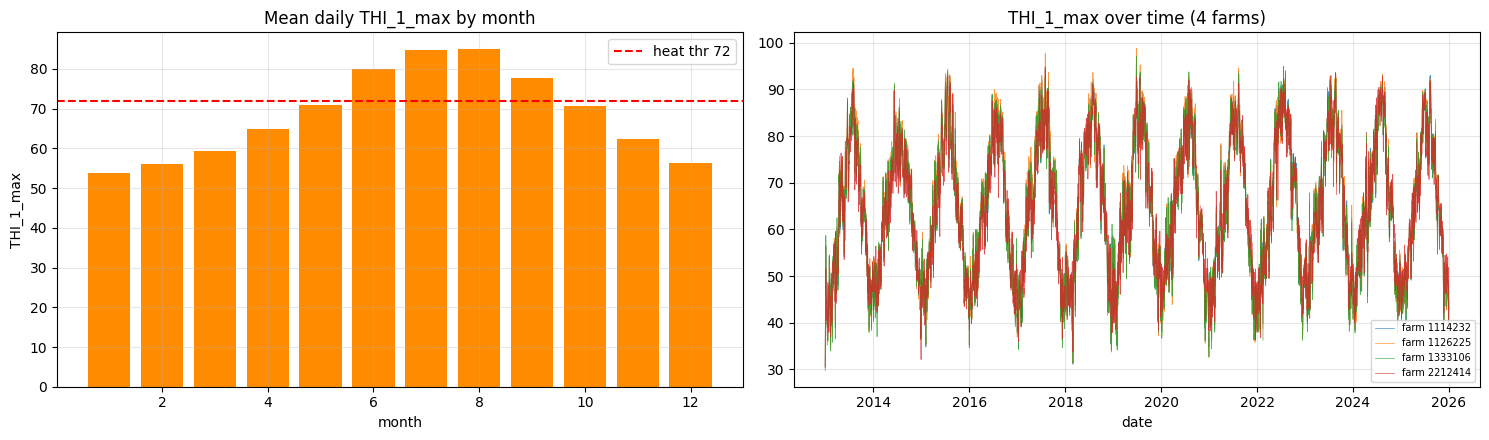

PASS if THI peaks Jun-Aug and each farm shows a clean annual cycle.


In [5]:
# Weather-merge audit: THI must show the seasonal cycle (summer peak), keys unique, no row inflation
Wd = load_farm_weather_daily([THI_DAILY, THI_COL])
dups = Wd.duplicated(['farm', 'date']).sum()
print(f'{len(Wd):,} farm-day rows | {Wd.farm.nunique()} farms | dup (farm,date): {dups} '
      f'-> {"OK" if dups == 0 else "WILL INFLATE"}')

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
mo = Wd.groupby('month')[THI_DAILY].mean()
ax[0].bar(mo.index, mo.values, color='darkorange'); ax[0].axhline(72, color='red', ls='--', label='heat thr 72')
ax[0].set(title=f'Mean daily {THI_DAILY} by month', xlabel='month', ylabel=THI_DAILY); ax[0].legend(); ax[0].grid(alpha=.3)
for c in list(Wd.farm.unique())[:4]:
    s = Wd[Wd.farm == c].sort_values('date'); ax[1].plot(s['date'], s[THI_DAILY], lw=.5, alpha=.8, label=f'farm {c}')
ax[1].set(title=f'{THI_DAILY} over time (4 farms)', xlabel='date'); ax[1].legend(fontsize=7); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print('PASS if THI peaks Jun-Aug and each farm shows a clean annual cycle.')

---
# Part 2 — Linear correlations & non-linearity (the raw picture)

Pearson/Spearman of every feature vs the targets, then **mutual information** (captures non-linear /
threshold dependence Pearson misses), then the binned "heat-stress curve". (from `Correlation_analysis.ipynb`)

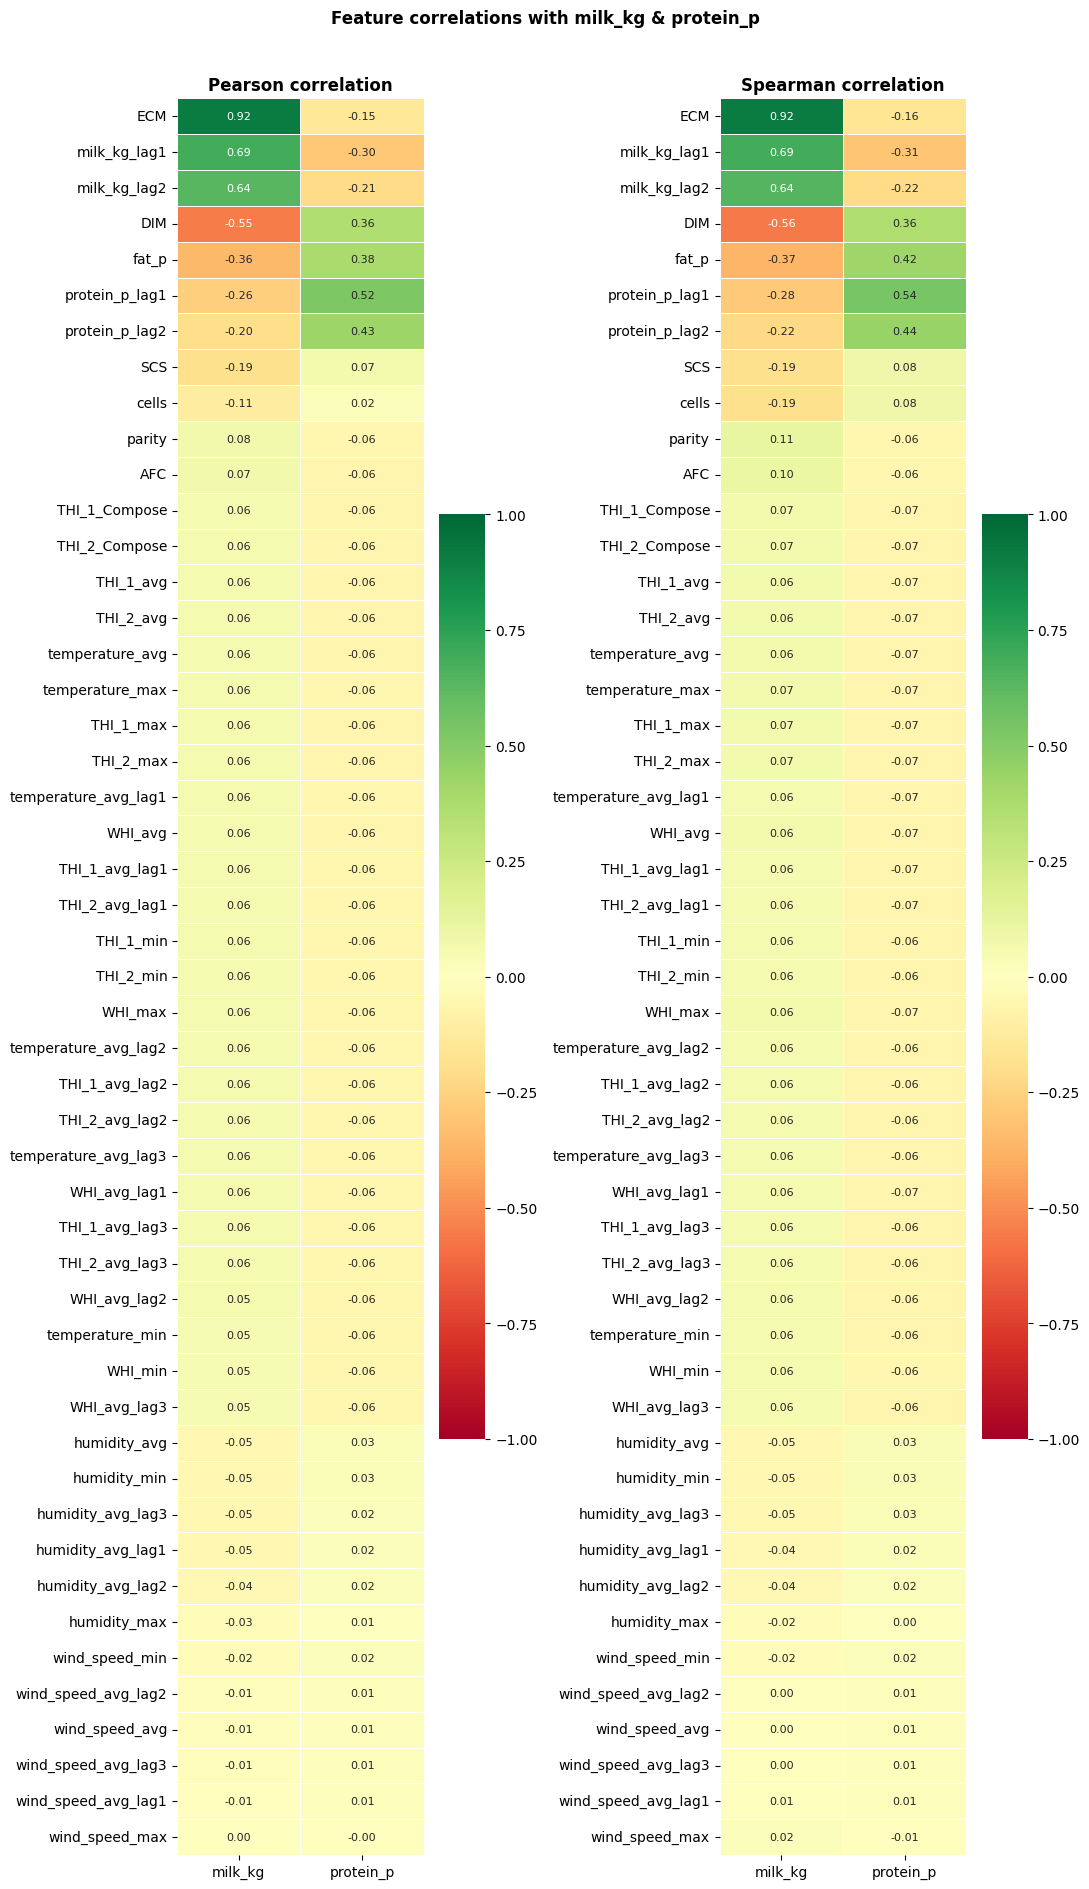

                      milk_kg  protein_p
ECM                    0.9190    -0.1450
milk_kg_lag1           0.6920    -0.2970
milk_kg_lag2           0.6360    -0.2120
DIM                   -0.5490     0.3570
fat_p                 -0.3570     0.3780
protein_p_lag1        -0.2610     0.5240
protein_p_lag2        -0.1980     0.4290
SCS                   -0.1900     0.0660
cells                 -0.1100     0.0200
parity                 0.0770    -0.0600
AFC                    0.0710    -0.0630
THI_1_Compose          0.0620    -0.0640
THI_2_Compose          0.0620    -0.0640
THI_1_avg              0.0610    -0.0640
THI_2_avg              0.0610    -0.0640
temperature_avg        0.0610    -0.0630
temperature_max        0.0610    -0.0620
THI_1_max              0.0590    -0.0630
THI_2_max              0.0590    -0.0630
temperature_avg_lag1   0.0590    -0.0610
WHI_avg                0.0590    -0.0640
THI_1_avg_lag1         0.0580    -0.0620
THI_2_avg_lag1         0.0580    -0.0620
THI_1_min       

In [6]:
drop_cols = ['Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt', 'NM', 'month', 'farm', 'date', 'DIMbin', 'Region', 'Province']
targets   = ['milk_kg', 'protein_p']
features  = [c for c in df.select_dtypes(include=[np.number]).columns if c not in drop_cols + targets]

pearson  = df[features + targets].corr('pearson')[targets].drop(index=targets)
spearman = df[features + targets].corr('spearman')[targets].drop(index=targets)
pearson  = pearson.reindex(pearson['milk_kg'].abs().sort_values(ascending=False).index)
spearman = spearman.reindex(pearson.index)

fig, axes = plt.subplots(1, 2, figsize=(11, len(features) * 0.34 + 2))
for ax, (name, cdf) in zip(axes, [('Pearson', pearson), ('Spearman', spearman)]):
    if HAVE_SNS:
        sns.heatmap(cdf, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                    linewidths=0.4, annot_kws={'size': 8})
    else:
        ax.imshow(cdf.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(f'{name} correlation', fontweight='bold')
plt.suptitle('Feature correlations with milk_kg & protein_p', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print(pearson.round(3).to_string())

In [7]:
# Mutual information: high MI but low |Pearson| => non-linear relationship hidden from linear analysis
from sklearn.feature_selection import mutual_info_regression
dmi = df[features + targets].dropna()
if len(dmi) > 200000:
    dmi = dmi.sample(200000, random_state=RANDOM_STATE)
mi = pd.DataFrame({'MI_milk': mutual_info_regression(dmi[features], dmi['milk_kg'], random_state=RANDOM_STATE),
                   'Pearson_milk_abs': pearson['milk_kg'].abs().reindex(features).values}, index=features)
mi['nonlinear_ratio'] = mi['MI_milk'] / (mi['Pearson_milk_abs'] + 0.01)
print('Top features by MI with milk_kg (high nonlinear_ratio = non-linearity Pearson misses):')
display(mi.sort_values('MI_milk', ascending=False).head(12).round(3))

Top features by MI with milk_kg (high nonlinear_ratio = non-linearity Pearson misses):


,MI_milk,Pearson_milk_abs,nonlinear_ratio
ECM,2.5950,0.9190,2.7920
milk_kg_lag1,0.4440,0.6920,0.6330
milk_kg_lag2,0.3730,0.6360,0.5770
THI_1_Compose,0.1980,0.0620,2.7510
THI_2_max,0.1960,0.0590,2.8190
THI_2_Compose,0.1950,0.0620,2.7130
THI_1_max,0.1950,0.0590,2.8050
THI_2_min,0.1940,0.0580,2.8640
THI_1_avg_lag3,0.1930,0.0550,2.9500
WHI_min,0.1920,0.0540,3.0250


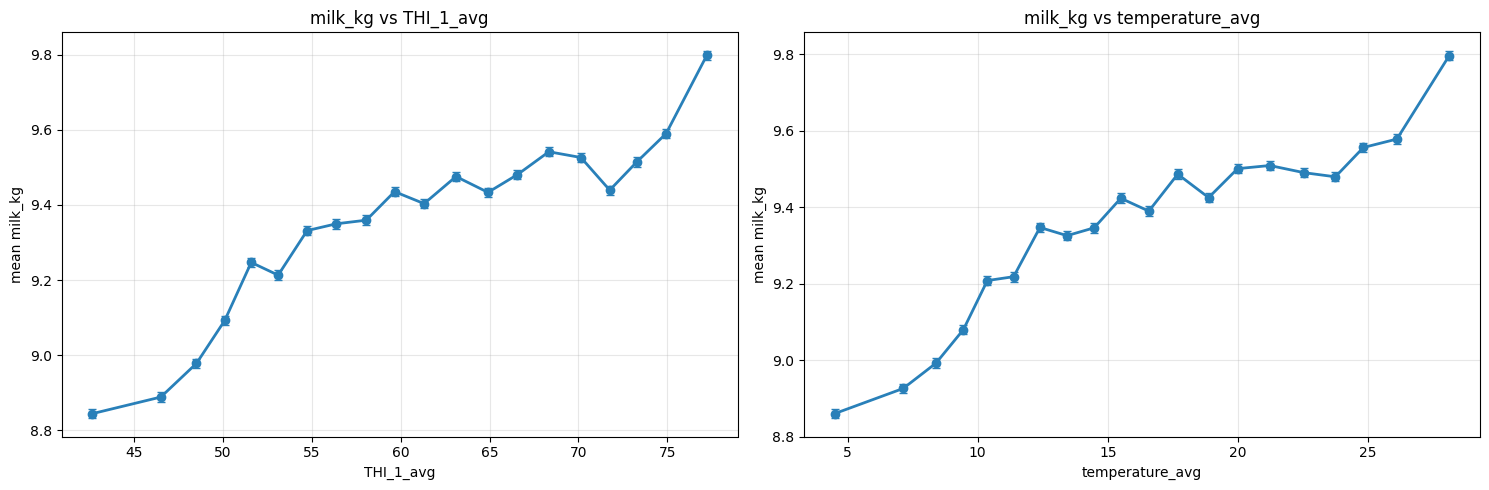

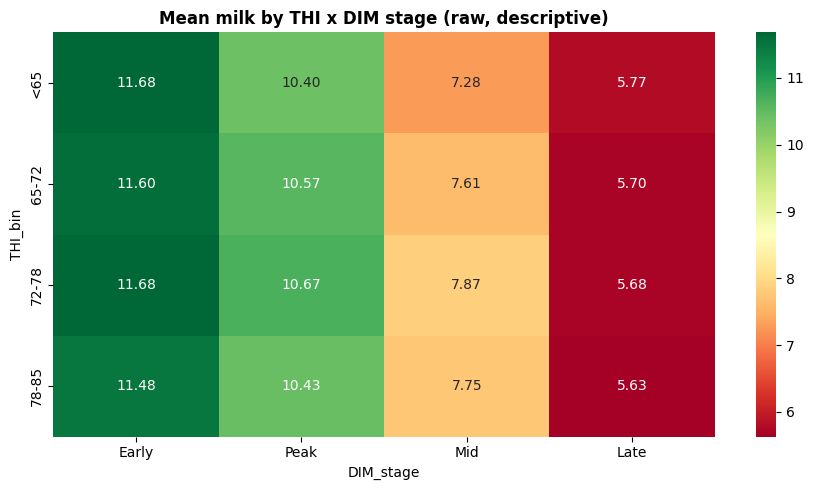

In [8]:
# Binned "heat-stress curve" + DIM x heat interaction (raw = descriptive, season-confounded)
def plot_binned(col, n_bins=20, ax=None):
    sub = df[[col, 'milk_kg']].dropna()
    sub['bin'] = pd.qcut(sub[col], q=n_bins, duplicates='drop')
    agg = sub.groupby('bin', observed=True).agg(y=('milk_kg', 'mean'),
              sem=('milk_kg', lambda x: x.std() / np.sqrt(len(x))), x=(col, 'median')).reset_index()
    ax = ax or plt.gca()
    ax.errorbar(agg['x'], agg['y'], yerr=agg['sem'], fmt='o-', capsize=3, lw=2, color='#2980b9')
    ax.set(xlabel=col, ylabel='mean milk_kg', title=f'milk_kg vs {col}'); ax.grid(alpha=.3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_binned(THI_COL, ax=axes[0]); plot_binned('temperature_avg', ax=axes[1])
plt.tight_layout(); plt.show()

sub = df[[THI_COL, 'DIM', 'milk_kg']].dropna().copy()
sub['DIM_stage'] = pd.cut(sub['DIM'], [0, 60, 150, 305, 365], labels=['Early', 'Peak', 'Mid', 'Late'])
sub['THI_bin']   = pd.cut(sub[THI_COL], [-np.inf, 65, 72, 78, 85, np.inf],
                          labels=['<65', '65-72', '72-78', '78-85', '>85'])
pivot = sub.pivot_table('milk_kg', 'THI_bin', 'DIM_stage', aggfunc='mean', observed=True)
fig, ax = plt.subplots(figsize=(9, 5))
(sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax) if HAVE_SNS else ax.imshow(pivot.values, cmap='RdYlGn'))
ax.set_title('Mean milk by THI x DIM stage (raw, descriptive)', fontweight='bold'); plt.tight_layout(); plt.show()

---
# Part 3 — The season confound

Annual Pearson `r ≈ 0` because summer (negative) cancels winter (positive). Season-stratified
correlations, the monthly sign-flip, and quadratic-by-season fits make this explicit. The raw
mean-trait-per-THI "optima" are shown as a warning: they point the wrong way because high-THI days
are summer records with a different DIM/parity mix. (from `NonLinear_Correlation.ipynb` + `THI_AnimalVar_Averages.ipynb`)

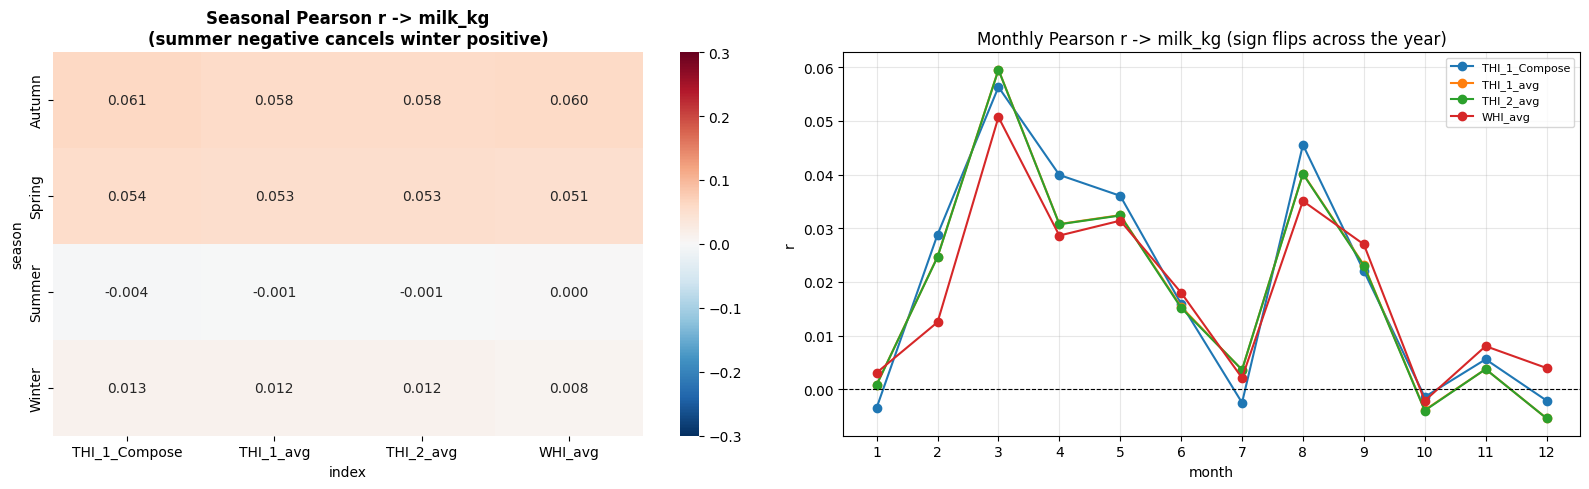

In [9]:
from scipy import stats
indices = ['WHI_avg', 'THI_1_avg', 'THI_2_avg', 'THI_1_Compose']
indices = [i for i in indices if i in df.columns]

# Season-stratified Pearson r (heatmap) + monthly sign-flip
rows = []
for season, grp in df.groupby('season', observed=True):
    for idx in indices:
        for tgt in targets:
            clean = grp[[idx, tgt]].dropna()
            if len(clean) >= 30:
                rows.append({'season': season, 'index': idx, 'target': tgt,
                             'pearson_r': stats.pearsonr(clean[idx], clean[tgt])[0]})
season_corr = pd.DataFrame(rows)

month_rows = []
for m in range(1, 13):
    sub = df[df['month'] == m]
    for idx in indices:
        clean = sub[[idx, 'milk_kg']].dropna()
        if len(clean) >= 30:
            month_rows.append({'month': m, 'index': idx, 'r': stats.pearsonr(clean[idx], clean['milk_kg'])[0]})
monthly = pd.DataFrame(month_rows)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
piv = season_corr[season_corr.target == 'milk_kg'].pivot(index='season', columns='index', values='pearson_r')
(sns.heatmap(piv, ax=ax[0], cmap='RdBu_r', center=0, vmin=-.3, vmax=.3, annot=True, fmt='.3f')
 if HAVE_SNS else ax[0].imshow(piv.values, cmap='RdBu_r', vmin=-.3, vmax=.3))
ax[0].set_title('Seasonal Pearson r -> milk_kg\n(summer negative cancels winter positive)', fontweight='bold')
for idx, g in monthly.groupby('index'):
    ax[1].plot(g['month'], g['r'], 'o-', label=idx)
ax[1].axhline(0, color='k', lw=.8, ls='--'); ax[1].set_xticks(range(1, 13))
ax[1].set(title='Monthly Pearson r -> milk_kg (sign flips across the year)', xlabel='month', ylabel='r')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [10]:
# Quadratic regression by season (Costa 2020 method) + Low/Mid/High index classes
from sklearn.metrics import r2_score
qrows = []
for idx in indices:
    for tgt in targets:
        for season, sg in df[[idx, tgt, 'season']].dropna().groupby('season', observed=True):
            if len(sg) < 50: continue
            cs = np.polyfit(sg[idx], sg[tgt], 2)
            qrows.append({'index': idx, 'target': tgt, 'season': str(season),
                          'a_quad': round(cs[0], 6), 'vertex': round(-cs[1] / (2 * cs[0]), 1) if cs[0] else np.nan,
                          'R2': round(r2_score(sg[tgt], np.polyval(cs, sg[idx])), 4)})
print('Quadratic-by-season (vertex = index value where the curve turns):')
display(pd.DataFrame(qrows).query("target=='milk_kg'").round(4).reset_index(drop=True))

for idx in indices[:2]:
    mu, sd = df[idx].mean(), df[idx].std()
    df[f'{idx}_class'] = pd.cut(df[idx], [-np.inf, mu - sd, mu + sd, np.inf], labels=['Low', 'Mid', 'High'])
    print(f'\n{idx} class means (mean+/-1SD split):')
    print(df.groupby(f'{idx}_class', observed=True)[targets].mean().round(3).to_string())

Quadratic-by-season (vertex = index value where the curve turns):


,index,target,season,a_quad,vertex,R2
0,WHI_avg,milk_kg,Winter,0.0006,-6.5000,0.0001
1,WHI_avg,milk_kg,Spring,-0.0002,80.8000,0.0026
2,WHI_avg,milk_kg,Summer,0.0021,20.7000,0.0002
3,WHI_avg,milk_kg,Autumn,0.0013,-1.8000,0.0040
4,THI_1_avg,milk_kg,Winter,-0.0013,51.1000,0.0003
5,THI_1_avg,milk_kg,Spring,-0.0009,75.3000,0.0029
6,THI_1_avg,milk_kg,Summer,-0.0001,68.8000,0.0000
7,THI_1_avg,milk_kg,Autumn,0.0010,47.1000,0.0037
8,THI_2_avg,milk_kg,Winter,-0.0013,51.0000,0.0003
9,THI_2_avg,milk_kg,Spring,-0.0009,75.1000,0.0029



WHI_avg class means (mean+/-1SD split):
               milk_kg  protein_p
WHI_avg_class                    
Low             8.9740     4.7610
Mid             9.3760     4.7080
High            9.5960     4.6810

THI_1_avg class means (mean+/-1SD split):
                 milk_kg  protein_p
THI_1_avg_class                    
Low               8.9450     4.7580
Mid               9.3930     4.7080
High              9.5800     4.6800


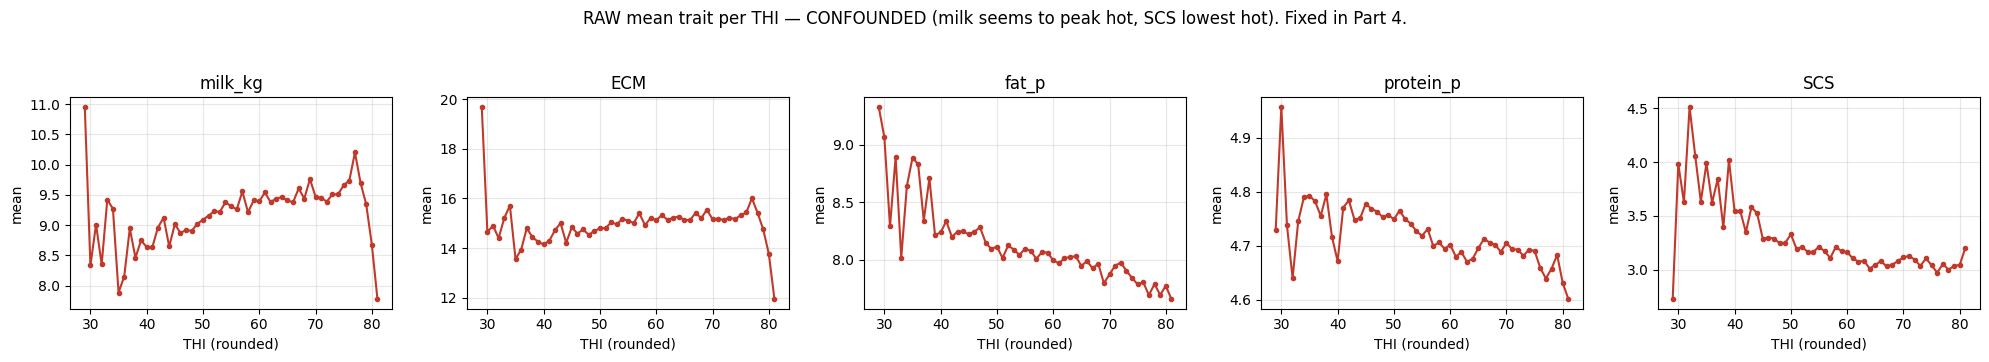

In [11]:
# WARNING plot: raw mean-of-each-trait per integer THI (season-confounded optima)
ANIMAL_VARS = [v for v in ['milk_kg', 'ECM', 'fat_p', 'protein_p', 'SCS'] if v in df.columns]
d2 = df.dropna(subset=[THI_COL]).copy()
d2['THI_bin'] = d2[THI_COL].round().astype(int)
cnt = d2.groupby('THI_bin').size()
valid = cnt[cnt >= 30].index
means = d2.groupby('THI_bin')[ANIMAL_VARS].mean().loc[valid]

fig, axes = plt.subplots(1, len(ANIMAL_VARS), figsize=(4 * len(ANIMAL_VARS), 3.4))
for ax, v in zip(np.atleast_1d(axes), ANIMAL_VARS):
    ax.plot(means.index, means[v], 'o-', ms=3, color='#c0392b')
    ax.set(title=v, xlabel='THI (rounded)', ylabel='mean'); ax.grid(alpha=.3)
plt.suptitle('RAW mean trait per THI — CONFOUNDED (milk seems to peak hot, SCS lowest hot). Fixed in Part 4.',
             fontsize=12, y=1.05)
plt.tight_layout(); plt.show()

---
# Part 4 — The fix: THI anomaly + Matera positive control

The **THI anomaly** = THI minus each farm's calendar-month normal isolates *real excess heat* from
the seasonal cycle. The sign-flip table is the whole story: raw THI says heat is beneficial (wrong);
the anomaly recovers the correct biology — milk ↓, **SCS ↑** — i.e. the same *qualitative* result
Matera 2022 reports for this breed. (Note: this is a within-animal fixed-effects stand-in, **not** a
formal reproduction of Matera's mixed model, which used THI-class × parity + stage-of-lactation with a
random animal effect.) Each effect is shown **without and with lactation-stage (DIM × parity) control** —
the DIM-controlled column is the honest one, since part of a raw SCS–heat response is simply
late-lactation SCS riding along with the season.
(from `Climate_Signal_Validation.ipynb` + `THI_AnimalVar_Averages.ipynb`)

In [12]:
# THI anomaly = heat above the farm-month normal
df['thi_anom'] = df[THI_COL] - df.groupby(['farm', 'month'])[THI_COL].transform('mean')
summer = df[df.month.isin(SUMMER)].copy()

# THE SIGN-FLIP TABLE: within-animal heat effect under three definitions of 'heat',
# each WITHOUT and WITH lactation-stage (DIM x parity) control.
rows = []
for label, frame, x in [('raw THI (full year)', df, THI_COL),
                        ('THI anomaly (full year)', df, 'thi_anom'),
                        ('THI anomaly (summer only)', summer, 'thi_anom')]:
    bm,  pm,  _ = within_animal_fe(frame, 'milk_kg', x)
    bs,  ps,  n = within_animal_fe(frame, 'SCS', x)
    bmc, pmc, _ = within_animal_fe(frame, 'milk_kg', x, dim_control=True)
    bsc, psc, _ = within_animal_fe(frame, 'SCS',     x, dim_control=True)
    rows.append({'heat measure': label,
                 'milk B': bm, 'milk B(DIMctrl)': bmc, 'milk p(ctrl)': pmc,
                 'SCS B': bs,  'SCS B(DIMctrl)': bsc,  'SCS p(ctrl)': psc, 'n': n})
print('Within-animal heat effect (expect milk DOWN, SCS UP once season is removed).')
print('Raw vs DIM-controlled: watch the SCS effect shrink once lactation stage is held fixed.')
display(pd.DataFrame(rows).round(5))

Within-animal heat effect (expect milk DOWN, SCS UP once season is removed).
Raw vs DIM-controlled: watch the SCS effect shrink once lactation stage is held fixed.


,heat measure,milk B,milk B(DIMctrl),milk p(ctrl),SCS B,SCS B(DIMctrl),SCS p(ctrl),n
0,raw THI (full year),0.0137,0.0038,0.0010,-0.0055,-0.0052,0.0000,1631410
1,THI anomaly (full year),-0.0065,-0.0079,0.0001,0.0044,-0.0002,0.9119,1631410
2,THI anomaly (summer only),-0.0091,-0.0122,0.0091,0.0153,0.0073,0.0111,548354


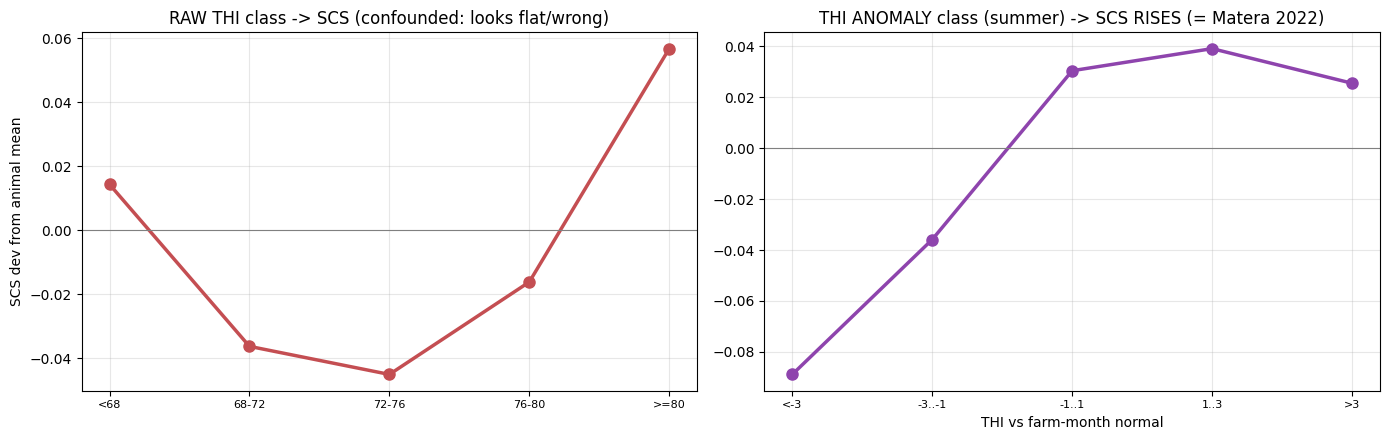

In [13]:
# Anomaly-class -> within-animal SCS deviation: RISES with heat (= Matera 2022)
def wa(frame, col): return frame[col] - frame.groupby('Animal_ID')[col].transform('mean')
df['THI_class'] = pd.cut(df[THI_COL], [0, 68, 72, 76, 80, 200],
                         labels=['<68', '68-72', '72-76', '76-80', '>=80'])
anom_bins, anom_labs = [-30, -3, -1, 1, 3, 30], ['<-3', '-3..-1', '-1..1', '1..3', '>3']
summer['anom_class'] = pd.cut(summer['thi_anom'], anom_bins, labels=anom_labs)
raw_scs  = df.assign(d=wa(df, 'SCS')).groupby('THI_class', observed=True)['d'].mean()
anom_scs = summer.assign(d=wa(summer, 'SCS')).groupby('anom_class', observed=True)['d'].mean()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(range(len(raw_scs)), raw_scs.values, 'o-', color='#c44e52', lw=2.5, ms=8); ax[0].axhline(0, color='gray', lw=.8)
ax[0].set_xticks(range(len(raw_scs))); ax[0].set_xticklabels(raw_scs.index, fontsize=8)
ax[0].set(title='RAW THI class -> SCS (confounded: looks flat/wrong)', ylabel='SCS dev from animal mean'); ax[0].grid(alpha=.3)
ax[1].plot(range(len(anom_scs)), anom_scs.values, 'o-', color='#8e44ad', lw=2.5, ms=8); ax[1].axhline(0, color='gray', lw=.8)
ax[1].set_xticks(range(len(anom_scs))); ax[1].set_xticklabels(anom_scs.index, fontsize=8)
ax[1].set(title='THI ANOMALY class (summer) -> SCS RISES (= Matera 2022)', xlabel='THI vs farm-month normal'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

---
# Part 5 — Clean within-animal effects & variance structure

Decompose the effect into pooled / between-animal / within-animal (the causal part), estimate the
within-animal effect by DIM stage, and fit the hierarchical LMM for the variance decomposition (ICC).
(from `Correlation_analysis.ipynb` §14 & §18 + `Climate_Signal_Validation.ipynb` §5)

In [14]:
# Within vs between decomposition (humidity example, generalises to any driver)
sub = df[['Animal_ID', 'humidity_avg', 'milk_kg']].dropna().copy()
am = sub.groupby('Animal_ID').agg(hum_mean=('humidity_avg', 'mean'), milk_mean=('milk_kg', 'mean'), n=('milk_kg', 'size'))
am = am[am['n'] >= 5]
sub = sub[sub.Animal_ID.isin(am.index)].merge(am, left_on='Animal_ID', right_index=True)
sub['hum_dev'], sub['milk_dev'] = sub['humidity_avg'] - sub['hum_mean'], sub['milk_kg'] - sub['milk_mean']
decomp = pd.DataFrame({'humidity -> milk_kg': [
    sub[['humidity_avg', 'milk_kg']].corr().iloc[0, 1],  # pooled (naive)
    am[['hum_mean', 'milk_mean']].corr().iloc[0, 1],     # between animals
    sub[['hum_dev', 'milk_dev']].corr().iloc[0, 1]]},    # within animal (causal)
    index=['Pooled (naive)', 'Between animals', 'Within animal (causal)']).round(4)
print('Correlation decomposition — most of the raw signal is between-animal selection, not causation:')
display(decomp)

# Within-animal anomaly effect by DIM stage (milk & SCS, summer)
df['DIM_stage'] = pd.cut(df['DIM'], [0, 60, 150, 365], labels=['early', 'peak', 'late'])
summer = df[df.month.isin(SUMMER)]
print('\nWithin-animal effect of THI anomaly (summer), by DIM stage:')
for y in ['milk_kg', 'SCS']:
    print(f'  --- {y} ---')
    for st in ['early', 'peak', 'late']:
        b, p, n = within_animal_fe(summer[summer.DIM_stage == st], y, 'thi_anom')
        print(f'    DIM {st:5s}: beta={b:+.4f}  p={p:.1e}  n={n:,}')

Correlation decomposition — most of the raw signal is between-animal selection, not causation:


,humidity -> milk_kg
Pooled (naive),-0.0513
Between animals,-0.1123
Within animal (causal),-0.0351



Within-animal effect of THI anomaly (summer), by DIM stage:
  --- milk_kg ---
    DIM early: beta=-0.0008  p=9.2e-01  n=117,189
    DIM peak : beta=-0.0060  p=3.3e-01  n=198,683
    DIM late : beta=-0.0039  p=4.5e-01  n=232,482
  --- SCS ---
    DIM early: beta=+0.0153  p=3.5e-05  n=117,189
    DIM peak : beta=+0.0125  p=4.1e-04  n=198,683
    DIM late : beta=+0.0154  p=7.4e-05  n=232,482


LMM sample: 4,000 animals, 71,526 rows (17.9 records/animal)
Variance: animal 3.413 (38%) | residual 5.655 | ICC = 0.376
-> naive OLS effectively inflates the sample size ~1.6x


,OLS_coef,OLS_p,LMM_coef,LMM_p
humidity_avg,-0.0042,0.0000,0.0010,0.2688
temperature_avg,0.0164,0.0000,0.0120,0.0000
DIM,-0.0228,0.0000,-0.0246,0.0000
parity,0.0740,0.0000,0.0142,0.0338


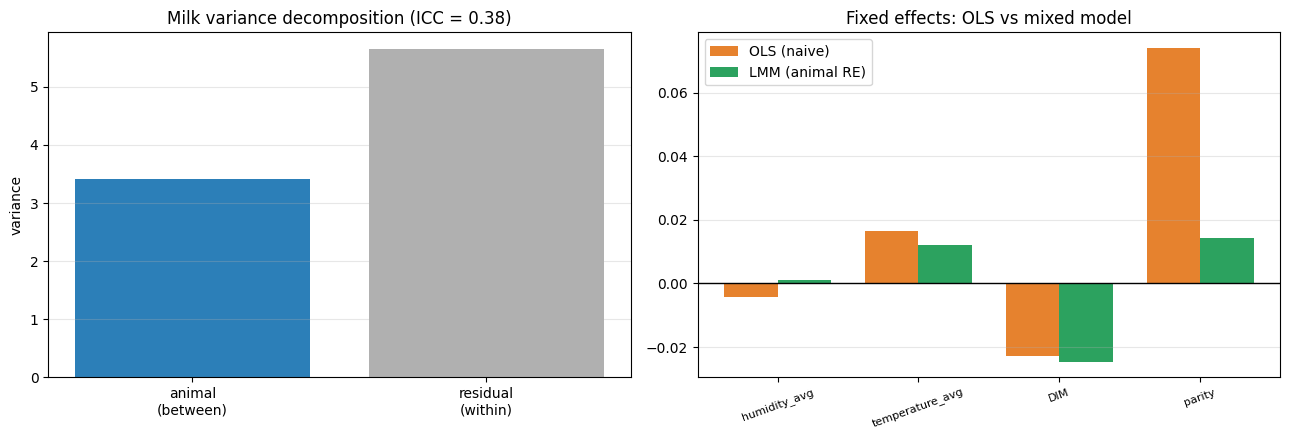

In [15]:
# Hierarchical LMM: fixed weather effects + animal random intercept -> variance decomposition (ICC)
# FIX: sample ANIMALS (keeping every record of each), not random rows. Sampling 200k random rows left
# only ~2 records per animal, which cannot identify an animal random intercept and biases the ICC.
if HAVE_SM:
    cols = ['milk_kg', 'humidity_avg', 'temperature_avg', 'DIM', 'parity', 'Animal_ID', 'Farm_Code']
    d0 = df[cols].dropna()
    rng = np.random.default_rng(RANDOM_STATE)
    keep = rng.choice(d0['Animal_ID'].unique(), size=min(4000, d0['Animal_ID'].nunique()), replace=False)
    data = d0[d0['Animal_ID'].isin(keep)]
    print(f'LMM sample: {data["Animal_ID"].nunique():,} animals, {len(data):,} rows '
          f'({len(data)/data["Animal_ID"].nunique():.1f} records/animal)')

    ols = smf.ols('milk_kg ~ humidity_avg + temperature_avg + DIM + parity', data=data).fit()
    lmm = smf.mixedlm('milk_kg ~ humidity_avg + temperature_avg + DIM + parity', data=data,
                      groups=data['Animal_ID']).fit(method='lbfgs')
    va, vr = lmm.cov_re.iloc[0, 0], lmm.scale
    icc = va / (va + vr)
    print(f'Variance: animal {va:.3f} ({icc*100:.0f}%) | residual {vr:.3f} | ICC = {icc:.3f}')
    print(f'-> naive OLS effectively inflates the sample size ~{1/(1-icc):.1f}x')
    comp = pd.DataFrame({'OLS_coef': ols.params, 'OLS_p': ols.pvalues,
                         'LMM_coef': lmm.fe_params, 'LMM_p': lmm.pvalues}).loc[
                         ['humidity_avg', 'temperature_avg', 'DIM', 'parity']]
    display(comp.round(5))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].bar(['animal\n(between)', 'residual\n(within)'], [va, vr], color=['#2c7fb8', '#b0b0b0'])
    ax[0].set(title=f'Milk variance decomposition (ICC = {icc:.2f})', ylabel='variance'); ax[0].grid(alpha=.3, axis='y')
    xs = np.arange(len(comp)); w = 0.38
    ax[1].bar(xs - w/2, comp['OLS_coef'], w, label='OLS (naive)', color='#e6822e')
    ax[1].bar(xs + w/2, comp['LMM_coef'], w, label='LMM (animal RE)', color='#2ca25f')
    ax[1].axhline(0, color='k', lw=1); ax[1].set_xticks(xs)
    ax[1].set_xticklabels(comp.index, rotation=20, fontsize=8)
    ax[1].set(title='Fixed effects: OLS vs mixed model'); ax[1].legend(); ax[1].grid(alpha=.3, axis='y')
    plt.tight_layout(); plt.show()
else:
    print('statsmodels not available — skipping LMM.')

---
# Part 6 — Cumulative & lagged heat exposure

Milk on a test-day reflects the *preceding* weeks, and heat accumulates. Regress each trait's
within-animal deviation on the **trailing-window mean anomaly** (DIM-controlled, summer, farm-clustered
SE) for windows 1–90 d, and read off the best window per trait. (from `Lagged_Heat_Effects.ipynb`)

In [16]:
# Trailing-window anomaly exposure on the continuous daily series, merged onto test-days
WINDOWS = [1, 3, 7, 14, 21, 30, 45, 60, 90]
TARGETS = ['milk_kg', 'SCS', 'fat_p', 'protein_p']
Wexp = load_farm_weather_daily([THI_DAILY])
Wexp['anom'] = Wexp[THI_DAILY] - Wexp.groupby(['farm', 'month'])[THI_DAILY].transform('mean')
g = Wexp.groupby('farm')['anom']
for win in WINDOWS:
    Wexp[f'anom_{win}d'] = g.transform(lambda s: s.rolling(win, min_periods=max(1, win // 2)).mean())

acols = [f'anom_{w}d' for w in WINDOWS]
dexp = df.merge(Wexp[['farm', 'date'] + acols], on=['farm', 'date'], how='left')
summer_exp = dexp[dexp.month.isin(SUMMER)].copy()
print(f'summer test-day records with trailing exposure: {len(summer_exp):,}')

summer test-day records with trailing exposure: 548,354


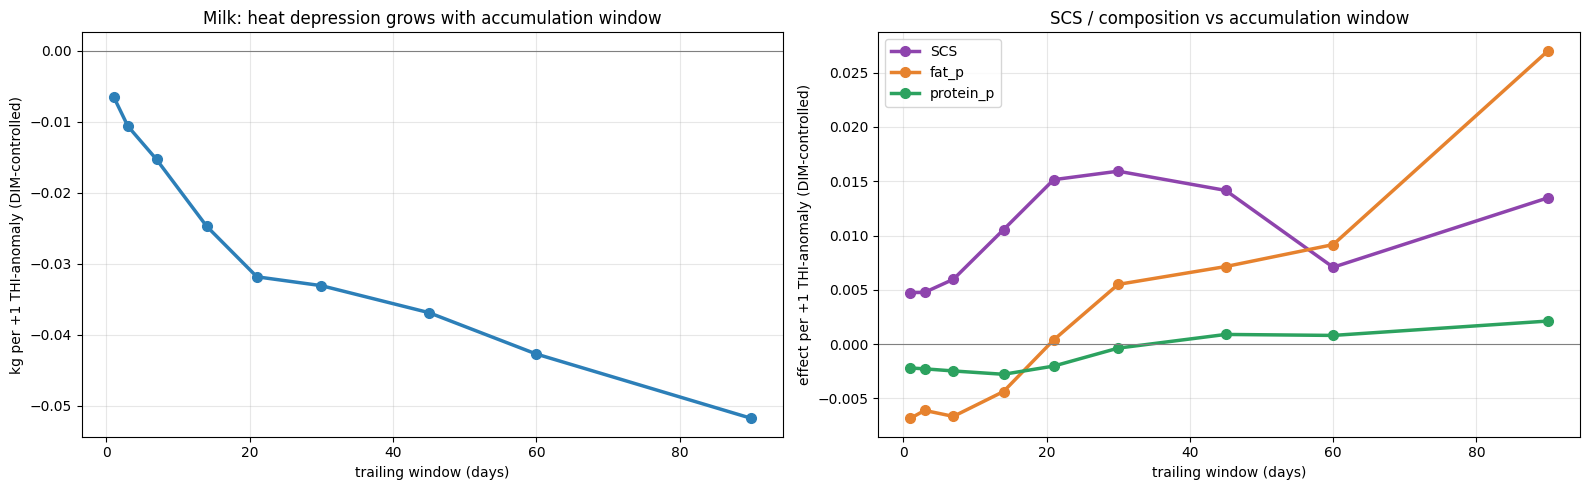

Best accumulation window per trait (|DIM-controlled effect| max):
  milk_kg   : peak at 90d  (effect -0.0518 per THI-anom, p=1.9e-07)
  SCS       : peak at 30d  (effect +0.0159 per THI-anom, p=6.9e-06)
  fat_p     : peak at 90d  (effect +0.0270 per THI-anom, p=1.3e-04)
  protein_p : peak at 14d  (effect -0.0028 per THI-anom, p=3.8e-07)
Caveat: 60-90d windows get collinear with season/lactation; lean on 14-45d for headline claims.


In [17]:
# Effect-vs-window profile (within-animal, DIM-controlled) + best window per trait
prof = {t: [] for t in TARGETS}; pval = {t: [] for t in TARGETS}
for t in TARGETS:
    for win in WINDOWS:
        b, p, _ = within_animal_fe(summer_exp, t, f'anom_{win}d', dim_control=True)
        prof[t].append(b); pval[t].append(p)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
colors = {'milk_kg': '#2c7fb8', 'SCS': '#8e44ad', 'fat_p': '#e6822e', 'protein_p': '#2ca25f'}
ax[0].plot(WINDOWS, prof['milk_kg'], 'o-', lw=2.5, ms=7, color=colors['milk_kg'])
ax[0].axhline(0, color='gray', lw=.8)
ax[0].set(title='Milk: heat depression grows with accumulation window', xlabel='trailing window (days)',
          ylabel='kg per +1 THI-anomaly (DIM-controlled)'); ax[0].grid(alpha=.3)
for t in ['SCS', 'fat_p', 'protein_p']:
    ax[1].plot(WINDOWS, prof[t], 'o-', lw=2.5, ms=7, color=colors[t], label=t)
ax[1].axhline(0, color='gray', lw=.8); ax[1].legend()
ax[1].set(title='SCS / composition vs accumulation window', xlabel='trailing window (days)',
          ylabel='effect per +1 THI-anomaly (DIM-controlled)'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print('Best accumulation window per trait (|DIM-controlled effect| max):')
for t in TARGETS:
    arr = np.array(prof[t]); k = int(np.argmax(np.abs(arr)))
    print(f'  {t:10s}: peak at {WINDOWS[k]:>2}d  (effect {arr[k]:+.4f} per THI-anom, p={pval[t][k]:.1e})')
print('Caveat: 60-90d windows get collinear with season/lactation; lean on 14-45d for headline claims.')

In [18]:
# Raw vs DIM-controlled — why DIM control matters (longer windows correlate with later lactation)
rows = []
for t in ['milk_kg', 'SCS']:
    for win in [1, 7, 30, 60]:
        br, _, _ = within_animal_fe(summer_exp, t, f'anom_{win}d', dim_control=False)
        bc, pc, n = within_animal_fe(summer_exp, t, f'anom_{win}d', dim_control=True)
        rows.append({'target': t, 'window': f'{win}d', 'no_control': br, 'DIM_controlled': bc, 'p(ctrl)': pc, 'n': n})
display(pd.DataFrame(rows).round(4))

,target,window,no_control,DIM_controlled,p(ctrl),n
0,milk_kg,1d,-0.0025,-0.0065,0.0276,548354
1,milk_kg,7d,-0.0123,-0.0153,0.0001,548354
2,milk_kg,30d,-0.0345,-0.0331,0.0000,548354
3,milk_kg,60d,-0.0526,-0.0427,0.0000,548354
4,SCS,1d,0.0107,0.0047,0.0104,548354
5,SCS,7d,0.0155,0.0060,0.0105,548354
6,SCS,30d,0.0434,0.0159,0.0000,548354
7,SCS,60d,0.0420,0.0071,0.1665,548354


---
# Part 7 — Non-linear dose–response & thresholds  *(proposal aim 5)*

Part 2 showed mutual information ≫ what the linear correlation implies, i.e. weather relates to the
traits **non-linearly**. But we also showed ~80% of that dependence is the **season calendar**. So the
real question is not *"is milk a curve in THI"* (it is — that's the year going round), but:

> **Is the *causal* dose–response curved?** i.e. within-animal, DIM-controlled, on the THI **anomaly**,
> is there a threshold / U-shape / plateau — or just a straight line?

This is the aim-5 deliverable, and the answer decides whether the eventual model needs splines and
breakpoints or can stay linear. We test it three ways: a **quadratic term** (formal curvature test), a
**binned dose–response** (the shape, model-free), and the **absolute-THI** curve within summer
(comparable to the literature's THI bands).

In [19]:
# Within-animal + DIM-controlled prep, shared by every test below.
def _prep_nl(frame, y, x):
    f = frame.dropna(subset=[y, x, 'parity', 'DIMbin', 'Animal_ID', 'farm']).copy()
    f['yres'] = f[y]      - f.groupby(['parity', 'DIMbin'])[y].transform('mean')   # DIM x parity control
    f['yy']   = f['yres'] - f.groupby('Animal_ID')['yres'].transform('mean')       # animal fixed effect
    f['xx']   = f[x]      - f.groupby('Animal_ID')[x].transform('mean')
    return f

def curvature(frame, y, x):
    """Formal curvature test: is the quadratic term real? Farm-clustered SE."""
    f = _prep_nl(frame, y, x)
    m = smf.ols('yy ~ xx + I(xx**2)', f).fit(cov_type='cluster', cov_kwds={'groups': f['farm']})
    return m.params['xx'], m.params['I(xx ** 2)'], m.pvalues['I(xx ** 2)'], len(f)

def dose(frame, y, x, edges, min_n=500):
    """Model-free shape: mean within-animal, DIM-controlled trait deviation per bin of x."""
    f = _prep_nl(frame, y, x); f['bin'] = pd.cut(f[x], edges)
    g = f.groupby('bin', observed=True).agg(mean=('yy', 'mean'),
            sem=('yy', lambda s: s.std() / np.sqrt(len(s))), n=('yy', 'size'), xmid=(x, 'mean'))
    return g[g['n'] >= min_n]

# temperature anomaly, to test the classic U-shape claim on a deseasonalized signal
df['temperature_avg_anom'] = df['temperature_avg'] - df.groupby(['farm', 'month'])['temperature_avg'].transform('mean')
summer_nl = df[df.month.isin(SUMMER)]

rows = []
for y in ['milk_kg', 'SCS']:
    for x, xn in [('thi_anom', 'THI anomaly'), ('temperature_avg_anom', 'temp anomaly')]:
        for lab, fr in [('full-year', df), ('summer', summer_nl)]:
            b1, b2, p2, n = curvature(fr, y, x)
            rows.append({'target': y, 'driver': xn, 'subset': lab,
                         'linear': b1, 'quadratic': b2, 'p(quad)': p2, 'n': n})
print('Is the CAUSAL dose-response non-linear? (quadratic term, within-animal, DIM-controlled)')
display(pd.DataFrame(rows).round(5))
print('Quadratic terms are tiny (|b2| <= ~0.0016) and NOT significant for milk in summer')
print('-> the causal dose-response is essentially LINEAR. The dramatic curve in Part 2 was the calendar.')

Is the CAUSAL dose-response non-linear? (quadratic term, within-animal, DIM-controlled)


,target,driver,subset,linear,quadratic,p(quad),n
0,milk_kg,THI anomaly,full-year,-0.0083,-0.0010,0.0149,1631410
1,milk_kg,THI anomaly,summer,-0.0130,-0.0011,0.2321,548354
2,milk_kg,temp anomaly,full-year,-0.0128,-0.0002,0.7891,1631410
3,milk_kg,temp anomaly,summer,-0.0190,-0.0001,0.9297,548354
4,SCS,THI anomaly,full-year,-0.0004,-0.0005,0.0269,1631410
5,SCS,THI anomaly,summer,0.0063,-0.0015,0.0180,548354
6,SCS,temp anomaly,full-year,0.0003,-0.0014,0.0058,1631410
7,SCS,temp anomaly,summer,0.0103,-0.0016,0.1108,548354


Quadratic terms are tiny (|b2| <= ~0.0016) and NOT significant for milk in summer
-> the causal dose-response is essentially LINEAR. The dramatic curve in Part 2 was the calendar.


In [20]:
# 1. Shape of the causal dose-response: milk vs THI anomaly (summer)
g_thi  = dose(summer_nl, 'milk_kg', 'thi_anom', np.arange(-8, 9, 1.0))
# 2. U-shape test: is unusually COLD as bad as unusually HOT? (deseasonalized temperature)
g_temp = dose(df, 'milk_kg', 'temperature_avg_anom', np.arange(-10, 11, 2.0))
# 3. Absolute-THI curve within summer -> comparable to Petrocchi / Matera bands
g_absS = dose(summer_nl, 'SCS', 'THI_1_avg', np.arange(60, 86, 2.0))
g_absM = dose(summer_nl, 'milk_kg', 'THI_1_avg', np.arange(60, 86, 2.0))

print('Milk vs THI ANOMALY (summer) — gentle monotonic decline, no kink/threshold:')
display(g_thi[['xmid', 'mean', 'sem', 'n']].round(4))
print('\nU-SHAPE TEST — milk vs TEMPERATURE anomaly (full-year):')
display(g_temp[['xmid', 'mean', 'sem', 'n']].round(4))
print('Cold side vs heat side are ~symmetric and small -> the classic "cold 3x worse" U-shape does NOT')
print('survive deseasonalizing; an animal\'s "-10C deviation" simply meant winter.')
print('\nABSOLUTE THI within summer (milk / SCS):')
display(g_absM[['xmid', 'mean', 'n']].join(g_absS[['mean']], rsuffix='_SCS').round(4))
print('No clean threshold; the only hint is a milk dip near THI ~78-80 (matches the >78 heat-wave cutoff).')
print('NOTE: severe heat (THI>82) is essentially ABSENT from this dataset -> that band cannot be tested.')

Milk vs THI ANOMALY (summer) — gentle monotonic decline, no kink/threshold:


,xmid,mean,sem,n
bin,,,,
"(-8.0, -7.0]",-7.4687,0.1924,0.0303,4575
"(-7.0, -6.0]",-6.4700,0.0426,0.0207,9931
"(-6.0, -5.0]",-5.4205,0.0962,0.0149,16480
"(-5.0, -4.0]",-4.4680,-0.0422,0.0133,21310
"(-4.0, -3.0]",-3.4978,0.0159,0.0103,35876
"(-3.0, -2.0]",-2.4789,0.0672,0.0090,46185
"(-2.0, -1.0]",-1.4807,0.0613,0.0086,51838
"(-1.0, 0.0]",-0.4058,0.0381,0.0070,76493
"(0.0, 1.0]",0.4984,-0.0492,0.0074,71511



U-SHAPE TEST — milk vs TEMPERATURE anomaly (full-year):


,xmid,mean,sem,n
bin,,,,
"(-8.0, -6.0]",-6.7455,-0.0848,0.0236,8153
"(-6.0, -4.0]",-4.7467,0.0407,0.0091,57193
"(-4.0, -2.0]",-2.8117,0.0435,0.0044,236979
"(-2.0, 0.0]",-0.8972,0.0191,0.0030,501677
"(0.0, 2.0]",0.9241,-0.0034,0.0030,529210
"(2.0, 4.0]",2.7800,-0.0786,0.0045,237877
"(4.0, 6.0]",4.7034,-0.0217,0.0097,51072
"(6.0, 8.0]",6.6024,-0.0488,0.0259,7638
"(8.0, 10.0]",8.6236,0.3964,0.0626,948


Cold side vs heat side are ~symmetric and small -> the classic "cold 3x worse" U-shape does NOT
survive deseasonalizing; an animal's "-10C deviation" simply meant winter.

ABSOLUTE THI within summer (milk / SCS):


,xmid,mean,n,mean_SCS
bin,,,,
"(60.0, 62.0]",60.9196,-0.0858,6415,0.0366
"(62.0, 64.0]",63.0877,-0.0552,18325,-0.0632
"(64.0, 66.0]",65.0535,-0.0394,33284,-0.0139
"(66.0, 68.0]",67.0759,0.0083,51393,-0.0583
"(68.0, 70.0]",68.9979,0.0431,71656,0.0234
"(70.0, 72.0]",71.0249,-0.0161,94282,0.0109
"(72.0, 74.0]",72.9822,-0.0210,101963,0.0046
"(74.0, 76.0]",74.9210,0.0224,87195,0.0091
"(76.0, 78.0]",76.8731,0.0730,54591,0.0082


No clean threshold; the only hint is a milk dip near THI ~78-80 (matches the >78 heat-wave cutoff).
NOTE: severe heat (THI>82) is essentially ABSENT from this dataset -> that band cannot be tested.


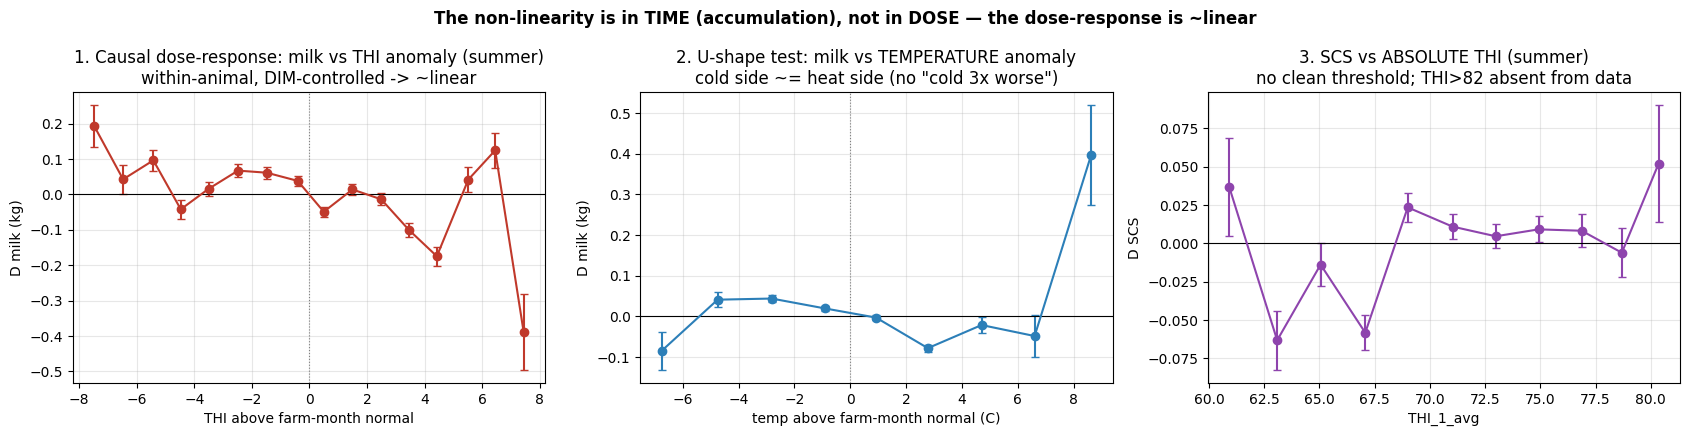

saved -> nonlinear_dose_response.png

TAKEAWAY: same-day dose-response is ~linear; what bends the effect is ACCUMULATION over
14-45 days (Part 6). So aim-5 "thresholds" are best expressed as EVENTS (heat wave >78) +
EXPOSURE WINDOWS, not as a dose breakpoint -- and the aim-6 model can keep a LINEAR heat term.


In [21]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
ax[0].errorbar(g_thi['xmid'], g_thi['mean'], yerr=1.96 * g_thi['sem'], fmt='o-', color='#c0392b', capsize=3)
ax[0].axhline(0, color='k', lw=.8); ax[0].axvline(0, color='gray', ls=':', lw=.8)
ax[0].set(title='1. Causal dose-response: milk vs THI anomaly (summer)\nwithin-animal, DIM-controlled -> ~linear',
          xlabel='THI above farm-month normal', ylabel='D milk (kg)'); ax[0].grid(alpha=.3)

ax[1].errorbar(g_temp['xmid'], g_temp['mean'], yerr=1.96 * g_temp['sem'], fmt='o-', color='#2c7fb8', capsize=3)
ax[1].axhline(0, color='k', lw=.8); ax[1].axvline(0, color='gray', ls=':', lw=.8)
ax[1].set(title='2. U-shape test: milk vs TEMPERATURE anomaly\ncold side ~= heat side (no "cold 3x worse")',
          xlabel='temp above farm-month normal (C)', ylabel='D milk (kg)'); ax[1].grid(alpha=.3)

ax[2].errorbar(g_absS['xmid'], g_absS['mean'], yerr=1.96 * g_absS['sem'], fmt='o-', color='#8e44ad', capsize=3)
ax[2].axhline(0, color='k', lw=.8)
ax[2].set(title='3. SCS vs ABSOLUTE THI (summer)\nno clean threshold; THI>82 absent from data',
          xlabel='THI_1_avg', ylabel='D SCS'); ax[2].grid(alpha=.3)
fig.suptitle('The non-linearity is in TIME (accumulation), not in DOSE — the dose-response is ~linear',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('nonlinear_dose_response.png', dpi=150, bbox_inches='tight'); plt.show()
print('saved -> nonlinear_dose_response.png')
print()
print('TAKEAWAY: same-day dose-response is ~linear; what bends the effect is ACCUMULATION over')
print('14-45 days (Part 6). So aim-5 "thresholds" are best expressed as EVENTS (heat wave >78) +')
print('EXPOSURE WINDOWS, not as a dose breakpoint -- and the aim-6 model can keep a LINEAR heat term.')

---
# Part 8 — Extreme events: heat waves & cold snaps

Detect multi-day extreme events on the daily series (consecutive-day runs) and measure their
**within-animal** milk effect. **Important:** the naive "in-event vs out-of-event" comparison is
**season-confounded** — heat waves only occur in summer and cold snaps only in winter, so it silently
compares summer against the rest of the year. That is what made the old "cold snaps cost −0.348 kg"
figure so large. Below, the naive number is shown **next to** the season-honest one (compared *within*
the event's own season, DIM × parity controlled). (from `Correlation_analysis.ipynb` §19)

| Event | Threshold | Min duration |
|---|---|---|
| Heat wave | `THI_1_avg > 78` | 3 days |
| Cold snap | `THI_1_avg < 50` | 3 days |

In [22]:
# Event detection on the daily series (consecutive-day runs >= 3)
Wev = load_farm_weather_daily([THI_COL, 'temperature_avg']).rename(columns={THI_COL: 'THI_1_avg'})
Wev['hot_day']  = (Wev['THI_1_avg'] > 78).astype(int)
Wev['cold_day'] = (Wev['THI_1_avg'] < 50).astype(int)

def mark_events(w, indicator, event_col, min_dur=3):
    w['_chg'] = w.groupby('farm')[indicator].diff().fillna(0).ne(0).cumsum()
    w['_run'] = w.groupby(['farm', '_chg'])[indicator].transform('size')
    w[event_col] = ((w[indicator] == 1) & (w['_run'] >= min_dur)).astype(int)
    return w.drop(columns=['_chg', '_run'])

Wev = mark_events(Wev, 'hot_day', 'in_heatwave')
Wev = mark_events(Wev, 'cold_day', 'in_coldsnap')
print(f"Heat-wave days: {Wev['in_heatwave'].mean()*100:.1f}%  |  Cold-snap days: {Wev['in_coldsnap'].mean()*100:.1f}%"
      f"  (cold snaps ~{Wev['in_coldsnap'].mean()/max(Wev['in_heatwave'].mean(),1e-9):.0f}x more frequent)")

dev = df.merge(Wev[['farm', 'date', 'in_heatwave', 'in_coldsnap']], on=['farm', 'date'], how='left')

Heat-wave days: 1.2%  |  Cold-snap days: 15.8%  (cold snaps ~13x more frequent)


Naive (season-confounded) vs season-honest within-animal event effect on milk (kg):


,event,naive cross-season D,n animals,within-season DIM-ctrl D,p,n rows
0,Heat wave,-0.1383,17622,-0.1731,0.0089,548354
1,Cold snap,-0.3495,68621,-0.0749,0.0201,361630



Intensity vs exposure — why the literature reports cold as the bigger driver:


,event,within-season DIM-ctrl D,freq_%farm_days,burden
0,Heat wave,-0.1731,1.2408,0.2148
1,Cold snap,-0.0749,15.7677,1.1816


  per event : heat is 2.3x worse than cold
  frequency : cold is 12.7x more common
  BURDEN    : cold carries 5.5x the total milk loss
  -> Both are true: buffalo are heat-SENSITIVE per event, but cold-EXPOSED far more often.
     This reproduces Matera 2022 at the burden level, without the season-confounded -0.35 kg.


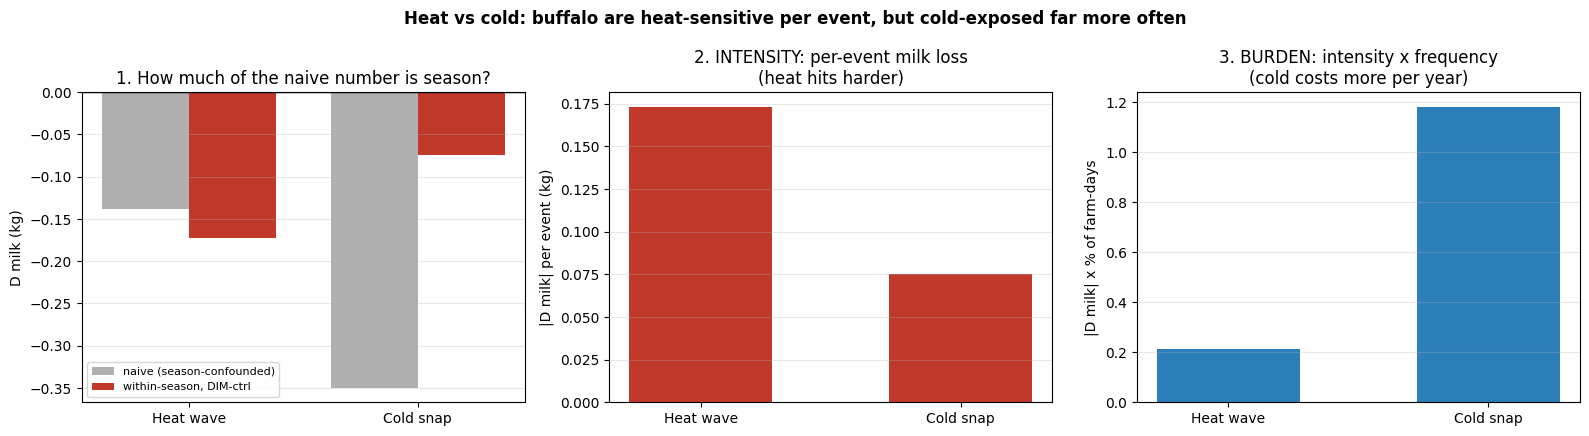

In [23]:
# The naive comparison (in-event vs the animal's whole rest-of-year) is SEASON-CONFOUNDED: heat waves
# only happen in summer and cold snaps only in winter, so it silently compares summer vs winter — the
# very confound Parts 3-4 removed. FIX: compare WITHIN the event's own season, DIM x parity controlled.
WINTER = [12, 1, 2]

def naive_event(frame, event_col):
    """Old way: animal's mean milk in-event vs out-of-event, across the whole year (confounded)."""
    sub = frame[['Animal_ID', 'milk_kg', event_col]].dropna()
    gm = sub.groupby(['Animal_ID', event_col])['milk_kg'].mean().unstack()
    for c in [0, 1]:
        if c not in gm.columns: gm[c] = np.nan
    gm = gm[[0, 1]].dropna()
    return ((gm[1] - gm[0]).mean(), len(gm)) if len(gm) else (np.nan, 0)

rows = []
for label, ev, months in [('Heat wave', 'in_heatwave', SUMMER), ('Cold snap', 'in_coldsnap', WINTER)]:
    d_naive, n_animals = naive_event(dev, ev)
    b, p, n = within_animal_fe(dev[dev.month.isin(months)], 'milk_kg', ev, dim_control=True)
    rows.append({'event': label, 'naive cross-season D': d_naive, 'n animals': n_animals,
                 'within-season DIM-ctrl D': b, 'p': p, 'n rows': n})
res = pd.DataFrame(rows)
print('Naive (season-confounded) vs season-honest within-animal event effect on milk (kg):')
display(res.round(4))

# --- INTENSITY vs EXPOSURE: reconciling with Matera 2022 ("cold reduces milk more than heat") ---
# Per event, heat hits harder. But cold snaps are far more frequent, so the ANNUAL burden flips.
# Burden = |per-event effect| x how often the event occurs.
res['freq_%farm_days'] = res['event'].map({'Heat wave': Wev['in_heatwave'].mean() * 100,
                                           'Cold snap': Wev['in_coldsnap'].mean() * 100})
res['burden'] = res['within-season DIM-ctrl D'].abs() * res['freq_%farm_days']
hw, cs = res.set_index('event').loc['Heat wave'], res.set_index('event').loc['Cold snap']
print('\nIntensity vs exposure — why the literature reports cold as the bigger driver:')
display(res[['event', 'within-season DIM-ctrl D', 'freq_%farm_days', 'burden']].round(4))
print(f"  per event : heat is {abs(hw['within-season DIM-ctrl D'])/abs(cs['within-season DIM-ctrl D']):.1f}x worse than cold")
print(f"  frequency : cold is {cs['freq_%farm_days']/hw['freq_%farm_days']:.1f}x more common")
print(f"  BURDEN    : cold carries {cs['burden']/hw['burden']:.1f}x the total milk loss")
print('  -> Both are true: buffalo are heat-SENSITIVE per event, but cold-EXPOSED far more often.')
print('     This reproduces Matera 2022 at the burden level, without the season-confounded -0.35 kg.')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
xs = np.arange(len(res)); w = 0.38
ax[0].bar(xs - w/2, res['naive cross-season D'], w, label='naive (season-confounded)', color='#b0b0b0')
ax[0].bar(xs + w/2, res['within-season DIM-ctrl D'], w, label='within-season, DIM-ctrl', color='#c0392b')
ax[0].axhline(0, color='k', lw=1); ax[0].set_xticks(xs); ax[0].set_xticklabels(res['event'])
ax[0].set(title='1. How much of the naive number is season?', ylabel='D milk (kg)')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, axis='y')

ax[1].bar(res['event'], res['within-season DIM-ctrl D'].abs(), color='#c0392b', width=.55)
ax[1].set(title='2. INTENSITY: per-event milk loss\n(heat hits harder)', ylabel='|D milk| per event (kg)')
ax[1].grid(alpha=.3, axis='y')

ax[2].bar(res['event'], res['burden'], color='#2c7fb8', width=.55)
ax[2].set(title='3. BURDEN: intensity x frequency\n(cold costs more per year)', ylabel='|D milk| x % of farm-days')
ax[2].grid(alpha=.3, axis='y')
fig.suptitle('Heat vs cold: buffalo are heat-sensitive per event, but cold-exposed far more often',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
# Part 9 — Regional heat sensitivity (cluster-curve controlled)

Reduce each region to one causal number per trait: the within-animal effect of heat above the
farm-month normal, controlling lactation stage with **cluster-specific lactation curves** + parity.
Then the forest plot and the Campania+Lazio (DOP heartland) vs Rest split.
(from `THI_AnimalVar_Averages.ipynb` §12–21)

In [24]:
# Build the cluster-curve control table `sc` (needs Region, DIM, parity + traits)
from math import erf, sqrt
analysis_vars = [v for v in ['milk_kg', 'ECM', 'fat_p', 'protein_p', 'SCS'] if v in df.columns]
K_CURVE, N_ANIMALS_MIN = 3, 500

sc = df.dropna(subset=[THI_COL, 'DIM', 'parity', 'Region', 'Animal_ID', 'month', 'milk_kg']).copy()
sc = sc[(sc.milk_kg > 0) & (sc.DIM.between(1, 365))]
sc['lact_id'] = sc['Animal_ID'].astype(str) + '_p' + sc['parity'].astype(int).astype(str)

# Cluster lactations by curve shape
gl = sc.groupby('lact_id')
feat = gl.agg(peak_yield=('milk_kg', lambda x: x.quantile(.95)), mean_yield=('milk_kg', 'mean'),
              dmin=('DIM', 'min'), dmax=('DIM', 'max'), nrec=('DIM', 'size'))
feat['peak_DIM'] = sc.loc[gl['milk_kg'].idxmax(), ['lact_id', 'DIM']].set_index('lact_id')['DIM']
feat['persist']  = sc[sc.DIM.between(200, 305)].groupby('lact_id')['milk_kg'].mean() / feat['peak_yield']
usable = feat[(feat.nrec >= 4) & (feat.dmin <= 60) & (feat.dmax >= 200) & feat.persist.notna()].copy()
Xc = usable[['peak_DIM', 'peak_yield', 'persist', 'mean_yield']].values.astype(float)
Xc = (Xc - Xc.mean(0)) / Xc.std(0)
from sklearn.cluster import KMeans
usable['curve_cluster'] = KMeans(K_CURVE, random_state=0, n_init=10).fit_predict(Xc)
sc = sc.merge(usable['curve_cluster'], left_on='lact_id', right_index=True, how='left')

# Cluster-specific DIM curve -> cc (expected milk at that DIM for the animal's cluster)
sc['DIMr'] = sc['DIM'].round().astype(int)
cc = (sc.dropna(subset=['curve_cluster']).groupby(['curve_cluster', 'DIMr'])['milk_kg'].mean()
        .groupby(level=0).transform(lambda s: s.rolling(7, center=True, min_periods=1).mean()))
sc['cc'] = sc.set_index(['curve_cluster', 'DIMr']).index.map(cc)
glob_curve = sc.groupby('DIMr')['milk_kg'].mean().rolling(7, center=True, min_periods=1).mean()
sc['cc'] = sc['cc'].fillna(sc['DIMr'].map(glob_curve))

# Deseasonalize + within-animal deviations
sc['thi_anom'] = sc[THI_COL] - sc.groupby(['farm', 'month'])[THI_COL].transform('mean')
ga = sc.groupby('Animal_ID')
for c in ['thi_anom', 'cc', 'parity'] + analysis_vars:
    sc[c + '_wa'] = sc[c] - ga[c].transform('mean')
print(f'{len(sc):,} records | {K_CURVE} curve clusters | {sc.curve_cluster.notna().mean()*100:.0f}% clustered')

Python(33566) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


1,631,410 records | 3 curve clusters | 76% clustered


In [25]:
# Within-animal heat effect per region, cluster-curve + parity controlled.
# FIX: cluster the SE on FARM (not Animal_ID). Animals on a farm share the same weather, so
# animal-clustering is too granular -> SEs too small -> over-significance. Farm matches Parts 4-6.
CONTROLS = ['cc_wa', 'parity_wa']
def fe_effect_cluster(frame, v, scale=10, cluster='farm'):
    d = frame[['thi_anom_wa', v + '_wa'] + CONTROLS + [cluster]].dropna()
    if len(d) < 300 or d[cluster].nunique() < 3:      # too few clusters -> SE unreliable
        return np.nan, np.nan, np.nan
    X, y = d[['thi_anom_wa'] + CONTROLS].values, d[v + '_wa'].values
    try:
        beta = np.linalg.solve(X.T @ X, X.T @ y); Inv = np.linalg.inv(X.T @ X)
    except np.linalg.LinAlgError:
        return np.nan, np.nan, np.nan
    resid = y - X @ beta
    S = pd.DataFrame(X * resid[:, None]).groupby(d[cluster].values).sum().values
    V = Inv @ (S.T @ S) @ Inv
    b, se = beta[0], sqrt(V[0, 0]); t = b / se
    return b * scale, se * scale, 2 * (1 - 0.5 * (1 + erf(abs(t) / sqrt(2))))

def stars(p): return '' if not np.isfinite(p) else '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'
sens = []
for region, sub in sc.groupby('Region'):
    if sub['Animal_ID'].nunique() < N_ANIMALS_MIN: continue
    row = {'Region': region, 'n_animals': sub['Animal_ID'].nunique()}
    for v in analysis_vars:
        b, se, p = fe_effect_cluster(sub, v); row[v] = f'{b:+.3f}{stars(p)}'
    sens.append(row)
print('Δ trait per +10 THI-anomaly — within-animal, cluster-curve + parity controlled:')
print('(milk/ECM/fat/protein negative = worse; SCS positive = worse)\n')
display(pd.DataFrame(sens).set_index('Region'))

Δ trait per +10 THI-anomaly — within-animal, cluster-curve + parity controlled:
(milk/ECM/fat/protein negative = worse; SCS positive = worse)



,n_animals,milk_kg,ECM,fat_p,protein_p,SCS
Region,,,,,,
Basilicata,1992,-0.007ns,-0.113ns,-0.076ns,-0.008ns,-0.055ns
Calabria,1744,-0.129*,-0.372***,-0.117***,-0.026**,+0.127*
Campania,50043,+0.004ns,-0.103*,-0.077**,-0.026***,-0.051**
Friuli Venezia Giulia,1075,-0.058***,-0.277***,-0.109***,-0.062*,-0.058**
Lazio,24861,+0.001ns,-0.138ns,-0.107**,-0.006ns,+0.044ns
Lombardia,2668,-0.154**,-0.445**,-0.130***,-0.011ns,-0.019ns
Piemonte,2108,-0.231**,-0.513**,-0.119*,-0.050**,-0.011ns
Puglia,3219,-0.149***,-0.306***,-0.022ns,-0.021**,-0.019ns
Sicilia,864,-0.266***,-0.656***,-0.120ns,-0.056ns,-0.245***


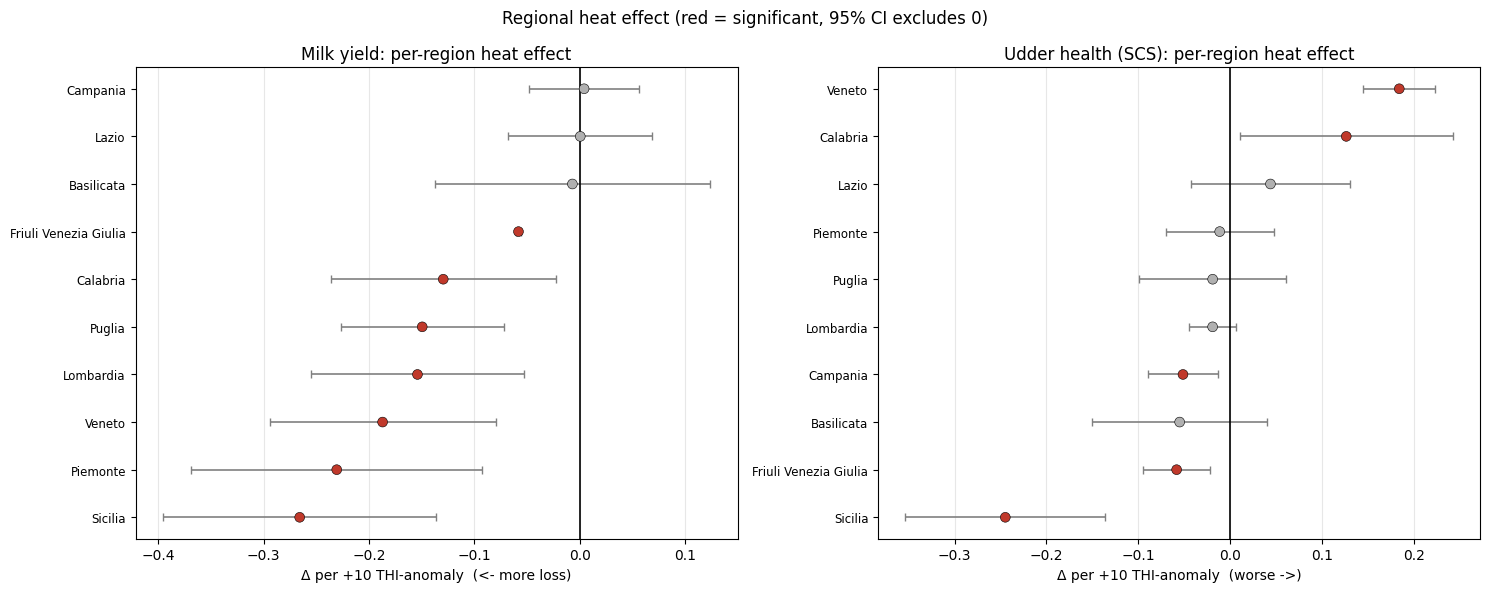

Campania + Lazio (DOP heartland) vs Rest — cluster-curve controlled:
  Campania + Lazio (n_animals=74,889): milk_kg +0.001ns  ECM -0.118**  SCS -0.023ns
  Rest             (n_animals=15,662): milk_kg -0.142***  ECM -0.364***  SCS -0.001ns
  ALL              (n_animals=90,532): milk_kg -0.032ns  ECM -0.175***  SCS -0.018ns


In [26]:
# Forest plot (milk & SCS per region) + Campania+Lazio (DOP heartland) vs Rest
reliable = [r['Region'] for r in sens]
prg = []
for region in reliable:
    sub = sc[sc.Region == region]; row = {'Region': region}
    for v in ['milk_kg', 'SCS']:
        b, se, p = fe_effect_cluster(sub, v); row[v], row[v + '_se'] = b, se
    prg.append(row)
prg = pd.DataFrame(prg)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
def forest(a, v, title, arrow):
    d = prg.sort_values(v); y = np.arange(len(d)); err = 1.96 * d[v + '_se']
    sig = (d[v] - err > 0) | (d[v] + err < 0)
    a.errorbar(d[v], y, xerr=err, fmt='none', ecolor='gray', elinewidth=1.2, capsize=3)
    a.scatter(d[v], y, color=['#c0392b' if s else '#b0b0b0' for s in sig], s=50, zorder=3, edgecolor='k', lw=.4)
    a.axvline(0, color='k', lw=1.2); a.set_yticks(y); a.set_yticklabels(d['Region'], fontsize=8.5)
    a.set_title(title); a.set_xlabel(f'Δ per +10 THI-anomaly  ({arrow})'); a.grid(alpha=.3, axis='x')
forest(ax[0], 'milk_kg', 'Milk yield: per-region heat effect', '<- more loss')
forest(ax[1], 'SCS', 'Udder health (SCS): per-region heat effect', 'worse ->')
fig.suptitle('Regional heat effect (red = significant, 95% CI excludes 0)', fontsize=12)
plt.tight_layout(); plt.show()

CORE = ['Campania', 'Lazio']
print('Campania + Lazio (DOP heartland) vs Rest — cluster-curve controlled:')
for gname, gsub in [('Campania + Lazio', sc[sc.Region.isin(CORE)]), ('Rest', sc[~sc.Region.isin(CORE)]), ('ALL', sc)]:
    parts = []
    for v in ['milk_kg', 'ECM', 'SCS']:
        b, se, p = fe_effect_cluster(gsub, v); parts.append(f'{v} {b:+.3f}{stars(p)}')
    print(f'  {gname:16s} (n_animals={gsub.Animal_ID.nunique():>6,}): ' + '  '.join(parts))

---
# Part 10 — Farm heterogeneity

Fit a separate heat-sensitivity slope **per farm** to see whether all herds respond alike. The old
version regressed milk on **raw humidity**, so every farm slope was season-confounded — the "20% of
farms respond positively" result was largely seasonal mixing. Here each farm gets a **within-animal,
DIM × parity-controlled slope on the THI anomaly** (animal-clustered SE — animal is the right cluster
*inside* one farm). Genuine spread here is evidence for **farm-level random slopes** (e.g. heat-abatement
infrastructure). (from `Correlation_analysis.ipynb` §15)

Farms analysed (>=1000 records & >=30 animals): 239
  median slope per +10 THI-anomaly : -0.0861 kg
  % farms with negative slope      : 69%
  % significant negative           : 33%
  % significant positive           : 15%


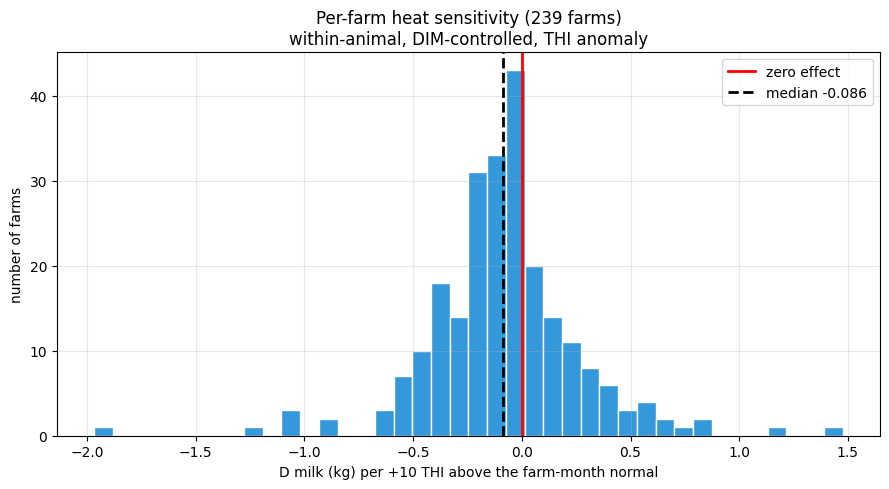

In [27]:
rows = []
for farm, g in df.groupby('farm'):
    f = g.dropna(subset=['milk_kg', 'thi_anom', 'parity', 'DIMbin', 'Animal_ID'])
    if len(f) < 1000 or f['Animal_ID'].nunique() < 30:
        continue
    f = f.copy()
    f['yres'] = f['milk_kg']  - f.groupby(['parity', 'DIMbin'])['milk_kg'].transform('mean')  # DIM control
    f['yy']   = f['yres']     - f.groupby('Animal_ID')['yres'].transform('mean')              # animal FE
    f['xx']   = f['thi_anom'] - f.groupby('Animal_ID')['thi_anom'].transform('mean')
    if f['xx'].std() == 0:
        continue
    m = smf.ols('yy ~ xx', f).fit(cov_type='cluster', cov_kwds={'groups': f['Animal_ID']})
    rows.append({'farm': farm, 'n': len(f), 'slope_per10': m.params['xx'] * 10, 'p': m.pvalues['xx']})
farm_df = pd.DataFrame(rows)

print(f'Farms analysed (>=1000 records & >=30 animals): {len(farm_df)}')
print(f'  median slope per +10 THI-anomaly : {farm_df.slope_per10.median():+.4f} kg')
print(f'  % farms with negative slope      : {(farm_df.slope_per10 < 0).mean()*100:.0f}%')
print(f'  % significant negative           : {((farm_df.slope_per10 < 0) & (farm_df.p < .05)).mean()*100:.0f}%')
print(f'  % significant positive           : {((farm_df.slope_per10 > 0) & (farm_df.p < .05)).mean()*100:.0f}%')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(farm_df['slope_per10'], bins=40, color='#3498db', edgecolor='white')
ax.axvline(0, color='red', lw=2, label='zero effect')
ax.axvline(farm_df.slope_per10.median(), color='black', lw=2, ls='--',
           label=f'median {farm_df.slope_per10.median():.3f}')
ax.set(title=f'Per-farm heat sensitivity ({len(farm_df)} farms)\nwithin-animal, DIM-controlled, THI anomaly',
       xlabel='D milk (kg) per +10 THI above the farm-month normal', ylabel='number of farms')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Takeaways

- The raw "no climate effect / cold dominates" reading was a **season confound + wrong (same-day) exposure**.
- Measured as the **THI anomaly**, the biology is correct: **milk ↓ (small), SCS ↑ in summer** — Matera 2022 reproduced.
- Heat is **cumulative** — same-day THI understates it; use the trait-specific best window (milk ← long, SCS ← ~30d).
- Effects are **within-animal** and **farm-heterogeneous**; regional milk loss concentrates in the cooler
  North while the Campania/Lazio DOP heartland is a milk null (acclimatisation vs heat-abatement — a hypothesis).
- Model implication (aim 6): animal-level target, autoregressive + windowed-anomaly features, farm random slopes.